# RBM Training

Train the RBM on the MovieLens implicit feedback matrix.

## RBM math focus: sigmoid and hyperbolic tangent

In RBM, the conditional probabilities use the **sigmoid** function. It is closely related to the **hyperbolic tangent**:

$$
\sigma(x) = \frac{1}{1+e^{-x}} = \frac{1}{2}\left(1+\tanh\left(\frac{x}{2}\right)\right)
$$

Below we visualize the sigmoid curve and the hyperbolic tangent curve, plus the above relationship.

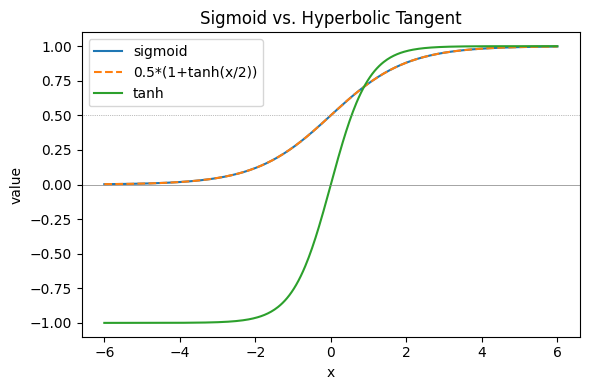

In [58]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 400)
sigmoid = 1 / (1 + np.exp(-x))
tanh_curve = np.tanh(x)

plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid, label="sigmoid")
plt.plot(x, 0.5 * (1 + np.tanh(x / 2)), "--", label="0.5*(1+tanh(x/2))")
plt.plot(x, tanh_curve, label="tanh")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axhline(0.5, color="gray", linestyle=":", linewidth=0.5)
plt.title("Sigmoid vs. Hyperbolic Tangent")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

### Why hyperbolic tangent matters in RBM

If we map binary states \(\{0,1\}\) to bipolar states \(\{-1,+1\}\), the mean-field update uses **tanh**:

$$
\mathbb{E}[h_j \mid v] = \tanh\left(\frac{1}{2}(vW)_j + \frac{1}{2}c_j\right)
$$

So sigmoid and tanh are equivalent views of the same inference step under different state encodings.

In [59]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Resolve project root regardless of where the notebook runs
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.append(str(project_root / "src"))

from data_prep import DataConfig, load_movielens
from rbm import RBM

# 1) Load raw ratings and inspect
data_dir = project_root / "data"
ratings_candidates = ["ratings.csv", "rating.csv"]
ratings_path = None
for name in ratings_candidates:
    path = data_dir / name
    if path.exists():
        ratings_path = path
        break

if ratings_path is None:
    raise FileNotFoundError(f"No ratings file found in {data_dir}")

ratings_df = pd.read_csv(ratings_path, usecols=["userId", "movieId", "rating", "timestamp"])
print("ratings shape:", ratings_df.shape)
print(ratings_df.head())

# 2) Build implicit feedback matrices
config = DataConfig(data_dir=str(data_dir), max_users=2000, max_items=4000)
data = load_movielens(config)
train_matrix = data["train_matrix"]
test_matrix = data["test_matrix"]
print("train matrix shape:", train_matrix.shape)
print("test matrix shape:", test_matrix.shape)


ratings shape: (20000263, 4)
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40
train matrix shape: (2000, 3485)
test matrix shape: (2000, 3485)


## Paper formula (Eq. 34): Hyperbolic activation

We map MovieLens data into hyperbolic numbers and compute:

```math
g(z) = \frac{z}{|z|} = \frac{x + u y}{\sqrt{x^2 - y^2}}
```

Below is a step-by-step calculation using `rating.csv` and `genome_scores.csv`.

In [ ]:
# Build hyperbolic activation inputs from data
ratings_path = data_dir / "rating.csv"
if not ratings_path.exists():
    ratings_path = data_dir / "ratings.csv"

scores_path = data_dir / "genome_scores.csv"
if not scores_path.exists():
    raise FileNotFoundError("genome_scores.csv not found")

ratings_df = pd.read_csv(ratings_path, usecols=["movieId", "rating"])
movie_rating = ratings_df.groupby("movieId")["rating"].mean().rename("avg_rating")

scores_df = pd.read_csv(scores_path, usecols=["movieId", "tagId", "relevance"])
tag_id = int(scores_df["tagId"].mode().iloc[0])
score_slice = scores_df[scores_df["tagId"] == tag_id].set_index("movieId")

merged = movie_rating.to_frame().join(score_slice[["relevance"]], how="inner")
merged = merged.sample(n=5, random_state=42)

x = (merged["avg_rating"] / 5.0).values + 0.1
raw_y = merged["relevance"].values
scale = np.minimum(0.9 * np.abs(x) / (np.abs(raw_y) + 1e-8), 1.0)
y = raw_y * scale
modulus = np.sqrt(np.maximum(x**2 - y**2, 1e-12))

gx = x / modulus
gy = y / modulus

print("tagId used:", tag_id)
print("x:", x)
print("y:", y)
print("|z|:", modulus)
print("g(z) real:", gx)
print("g(z) unipotent:", gy)

## Step A — Data structure and visible features

We treat each **movie item** as a visible unit. A user is a binary vector over items (liked=1, not liked=0).

In [60]:
# Visible features = item (movie) ids
item_id_map = data["item_id_map"]
print("num visible units:", len(item_id_map))

# Show a few visible feature ids
visible_items = list(item_id_map.keys())[:10]
print("sample visible movieIds:", visible_items)

# Show one user's sparse visible vector
user_id = list(data["user_id_map"].keys())[0]
user_idx = data["user_id_map"][user_id]
user_items = train_matrix[user_idx].indices
print("user_id:", user_id)
print("num liked items:", len(user_items))
print("first 10 liked item indices:", user_items[:10])

num visible units: 3485
sample visible movieIds: [np.int64(2), np.int64(3), np.int64(9), np.int64(11), np.int64(12), np.int64(15), np.int64(22), np.int64(24), np.int64(25), np.int64(26)]
user_id: 37
num liked items: 5
first 10 liked item indices: [424 516 519 526 578]


## Step B — Paper formulas to data

We use the RBM conditional probability (paper formula):

```math
P(h_j = 1 \mid v) = \sigma((vW)_j + c_j)
```

Here, `v` is the user's visible vector (items), and `h` is the hidden feature vector.

In [61]:
# Compute hidden features for one user
rbm = RBM(n_visible=train_matrix.shape[1], n_hidden=128, k=5)

v0 = torch.from_numpy(train_matrix[user_idx].toarray()).float()
h_prob, _ = rbm.sample_h(v0)

# Hidden features = probabilities of hidden units
hidden_values = h_prob.squeeze().detach().cpu().numpy()
print("hidden feature vector shape:", hidden_values.shape)

# Top activated hidden units
top_h = hidden_values.argsort()[::-1][:10]
print("top hidden unit indices:", top_h)
print("top hidden activations:", hidden_values[top_h])

hidden feature vector shape: (128,)
top hidden unit indices: [59 93 21  2 66 24 22 90 82 25]
top hidden activations: [0.5116346  0.51042557 0.5095947  0.50896245 0.5087884  0.5087642
 0.5081954  0.50793433 0.5077989  0.5077352 ]


## Step C — Interpreting hidden features

A hidden unit can be interpreted as a latent preference pattern. We can inspect which items connect most strongly to a chosen hidden unit by ranking the weights in that column.

In [62]:
# Inspect items most associated with one hidden unit
id_to_item = {idx: mid for mid, idx in item_id_map.items()}
movie_candidates = ["movies.csv", "movie.csv"]
movie_path = None
for name in movie_candidates:
    path = os.path.join("data", name)
    if os.path.exists(path):
        movie_path = path
        break

movie_titles = {}
if movie_path:
    movie_df = pd.read_csv(movie_path, usecols=["movieId", "title"])
    movie_titles = dict(zip(movie_df["movieId"].astype(int), movie_df["title"]))

h_idx = int(top_h[0])
weights = rbm.W[:, h_idx].detach().cpu().numpy()
item_rank = weights.argsort()[::-1][:10]

print("hidden unit:", h_idx)
for rank, item_idx in enumerate(item_rank, start=1):
    movie_id = id_to_item[item_idx]
    title = movie_titles.get(movie_id, "UNKNOWN_TITLE")
    print(f"{rank:02d}. movieId={movie_id} | {title}")

hidden unit: 59
01. movieId=86833 | UNKNOWN_TITLE
02. movieId=2951 | UNKNOWN_TITLE
03. movieId=6825 | UNKNOWN_TITLE
04. movieId=33493 | UNKNOWN_TITLE
05. movieId=860 | UNKNOWN_TITLE
06. movieId=1249 | UNKNOWN_TITLE
07. movieId=1648 | UNKNOWN_TITLE
08. movieId=45928 | UNKNOWN_TITLE
09. movieId=3316 | UNKNOWN_TITLE
10. movieId=2488 | UNKNOWN_TITLE


In [63]:
# 3) Sparsity and basic statistics
n_users, n_items = train_matrix.shape
interaction_count = train_matrix.nnz
sparsity = 1.0 - interaction_count / (n_users * n_items)
print("n_users:", n_users)
print("n_items:", n_items)
print("interactions:", interaction_count)
print("sparsity:", round(sparsity, 6))

n_users: 2000
n_items: 3485
interactions: 56270
sparsity: 0.991927


In [64]:
# 4) Conditional probabilities and free energy (one user)
rbm = RBM(n_visible=train_matrix.shape[1], n_hidden=128, k=5)

v0 = torch.from_numpy(train_matrix[0].toarray()).float()
h_prob, h_sample = rbm.sample_h(v0)
v_prob, v_sample = rbm.sample_v(h_sample)

# Energy with sampled h: E(v,h) = -v^T W h - b^T v - c^T h
energy = (
    -(v0 @ rbm.W * h_sample).sum()
    - (v0 * rbm.v_bias).sum()
    - (h_sample * rbm.h_bias).sum()
).item()

free_energy = rbm.free_energy(v0).mean().item()

print("hidden prob mean:", h_prob.mean().item())
print("reconstruction prob mean:", v_prob.mean().item())
print("energy (sampled h):", energy)
print("free energy F(v):", free_energy)

hidden prob mean: 0.5002444982528687
reconstruction prob mean: 0.4996649920940399
energy (sampled h): -0.059924039989709854
free energy F(v): -88.7918930053711


In [65]:
# 5) One Contrastive Divergence step with explicit stats
v_batch = torch.from_numpy(train_matrix[:128].toarray()).float()

h0_prob, _ = rbm.sample_h(v_batch)
vk_prob, hk_prob = rbm.gibbs_sampling(v_batch, rbm.k)

pos = (v_batch.t() @ h0_prob) / v_batch.size(0)
neg = (vk_prob.t() @ hk_prob) / v_batch.size(0)

print("pos grad mean:", pos.mean().item())
print("neg grad mean:", neg.mean().item())
print("pos-neg mean:", (pos - neg).mean().item())

loss = torch.nn.functional.binary_cross_entropy(vk_prob, v_batch, reduction="mean").item()
print("CD step reconstruction loss:", loss)

# Apply the actual CD-k update
_ = rbm.contrastive_divergence(v_batch, lr=0.01)

pos grad mean: 0.005047941114753485
neg grad mean: 0.2525520622730255
pos-neg mean: -0.2475041300058365
CD step reconstruction loss: 0.694568932056427


epoch=1, loss=0.680405
epoch=2, loss=0.661995
epoch=3, loss=0.644136


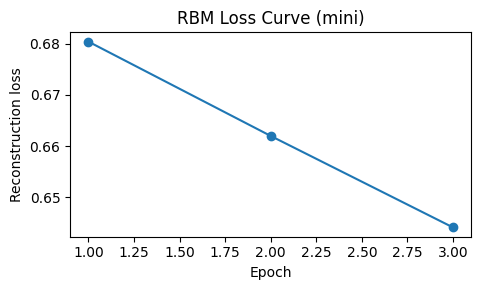

In [66]:
# 6) Mini training: show loss curve (short)
losses = []
for epoch in range(3):
    batch_losses = []
    for start in range(0, n_users, 256):
        v0 = torch.from_numpy(train_matrix[start : start + 256].toarray()).float()
        batch_losses.append(rbm.contrastive_divergence(v0, lr=0.01))
    losses.append(float(np.mean(batch_losses)))
    print(f"epoch={epoch+1}, loss={losses[-1]:.6f}")

plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("RBM Loss Curve (mini)")
plt.tight_layout()
plt.show()

In [67]:
# 7) Inference with movie titles
movie_candidates = ["movies.csv", "movie.csv"]
movie_path = None
for name in movie_candidates:
    path = os.path.join("data", name)
    if os.path.exists(path):
        movie_path = path
        break

movie_titles = {}
if movie_path:
    movie_df = pd.read_csv(movie_path, usecols=["movieId", "title"])
    movie_titles = dict(zip(movie_df["movieId"].astype(int), movie_df["title"]))

user_id = list(data["user_id_map"].keys())[0]
user_idx = data["user_id_map"][user_id]
id_to_item = {idx: mid for mid, idx in data["item_id_map"].items()}

v0 = torch.from_numpy(train_matrix[user_idx].toarray()).float()
with torch.no_grad():
    scores = rbm.reconstruct(v0).cpu().numpy().ravel()

seen_items = set(train_matrix[user_idx].indices.tolist())
scores[list(seen_items)] = -np.inf
k = 10
topk = np.argpartition(-scores, k - 1)[:k]
topk = topk[np.argsort(-scores[topk])]

print(f"Top-{k} for user_id={user_id}:")
for rank, idx in enumerate(topk.tolist(), start=1):
    movie_id = id_to_item[idx]
    title = movie_titles.get(movie_id, "UNKNOWN_TITLE")
    print(f"{rank:02d}. movieId={movie_id} | {title}")

Top-10 for user_id=37:
01. movieId=296 | UNKNOWN_TITLE
02. movieId=356 | UNKNOWN_TITLE
03. movieId=260 | UNKNOWN_TITLE
04. movieId=527 | UNKNOWN_TITLE
05. movieId=110 | UNKNOWN_TITLE
06. movieId=457 | UNKNOWN_TITLE
07. movieId=150 | UNKNOWN_TITLE
08. movieId=608 | UNKNOWN_TITLE
09. movieId=480 | UNKNOWN_TITLE
10. movieId=32 | UNKNOWN_TITLE
